In [19]:
import mne
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.preprocess import laplacian_filter, channel_aggregation

mne.set_log_level('WARNING')

In [20]:
data_path = '../datasets/BCICIV_2a_gdf'

data = load_all_subjects(data_path)

/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

Loaded file: ../datasets/BCICIV_2a_gdf/A07T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/opt/anaconda3/envs/py311ml/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


## EEG signal analisis for Subject 1, trial 1, class 0 (left hand)

In [21]:
trial_idx = 0

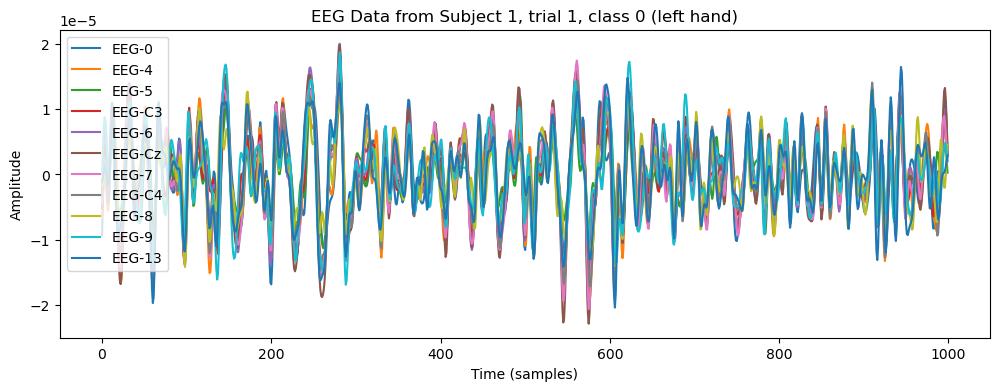

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][0], label='EEG-0')
plt.plot(data["X"][trial_idx][1], label='EEG-4')
plt.plot(data["X"][trial_idx][2], label='EEG-5')
plt.plot(data["X"][trial_idx][3], label='EEG-C3')
plt.plot(data["X"][trial_idx][4], label='EEG-6')
plt.plot(data["X"][trial_idx][5], label='EEG-Cz')
plt.plot(data["X"][trial_idx][6], label='EEG-7')
plt.plot(data["X"][trial_idx][7], label='EEG-C4')
plt.plot(data["X"][trial_idx][8], label='EEG-8')
plt.plot(data["X"][trial_idx][9], label='EEG-9')
plt.plot(data["X"][trial_idx][10], label='EEG-13')
plt.title('EEG Data from Subject 1, trial 1, class 0 (left hand)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

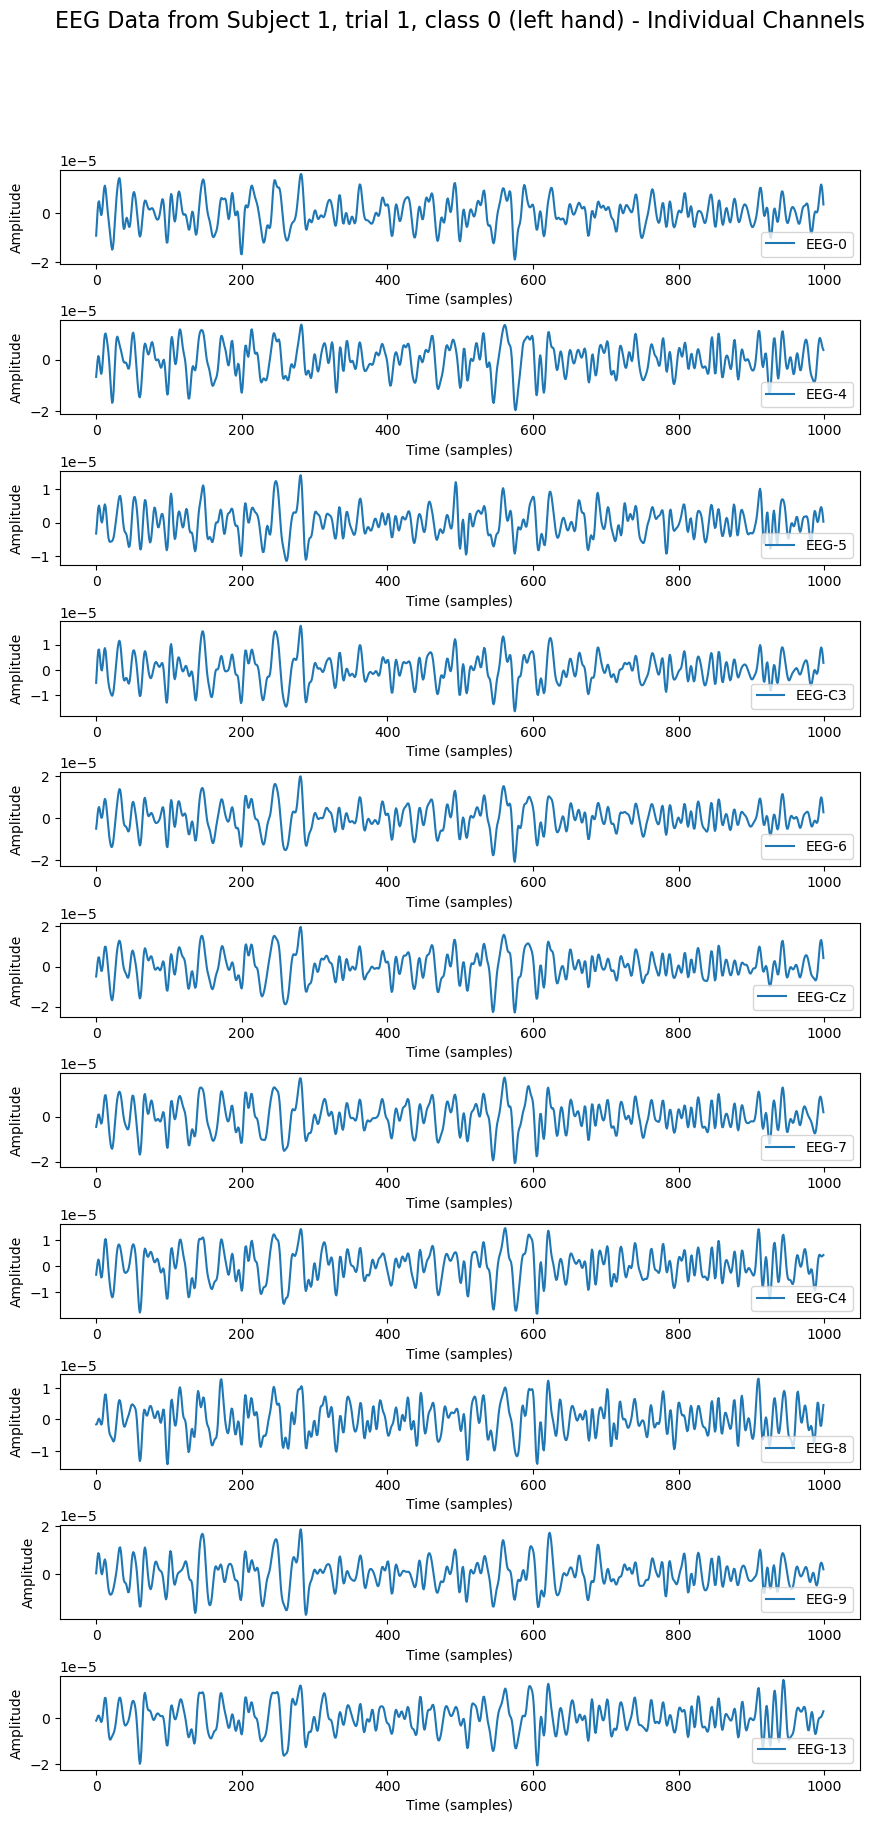

In [23]:
channel_labels = ['EEG-0', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7','EEG-C4', 'EEG-8', 'EEG-9', 'EEG-13']

fig, axes = plt.subplots(11, 1, figsize=(10, 20))

for i in range(11):
    axes[i].plot(data["X"][trial_idx][i], label=channel_labels[i])
    axes[i].set_xlabel('Time (samples)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='lower right')

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)

plt.suptitle('EEG Data from Subject 1, trial 1, class 0 (left hand) - Individual Channels', fontsize=16)
plt.show()

In [24]:
channels_laplace = [3,7] # C3 and C4
c3_neighbours = [0,2,4,9]
c4_neighbours = [1,6,8,10]

data_laplace = laplacian_filter(data['X'], channels_laplace, [c3_neighbours, c4_neighbours])

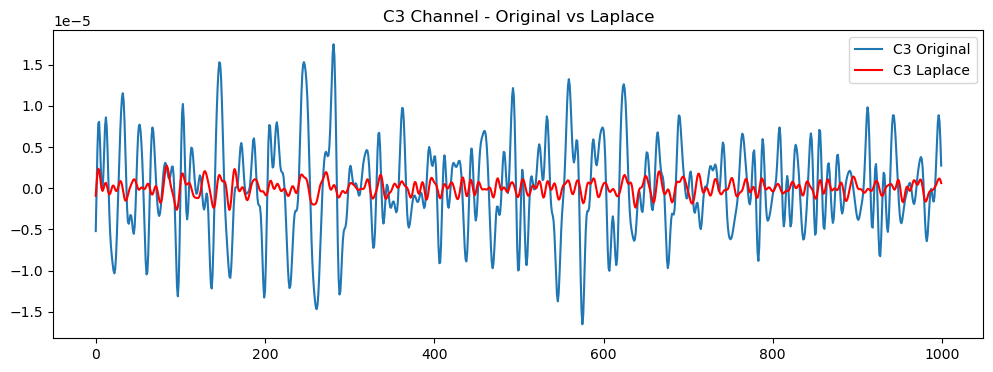

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][3], label='C3 Original')
plt.plot(data_laplace[trial_idx][3], label='C3 Laplace', color='red')
plt.title('C3 Channel - Original vs Laplace')
plt.legend()
plt.show()

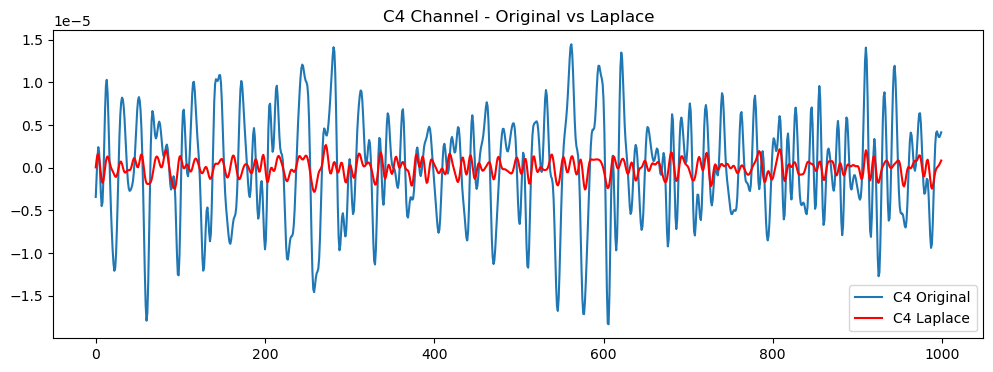

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][7], label='C4 Original')
plt.plot(data_laplace[trial_idx][7], label='C4 Laplace', color='red')
plt.title('C4 Channel - Original vs Laplace')
plt.legend()
plt.show()

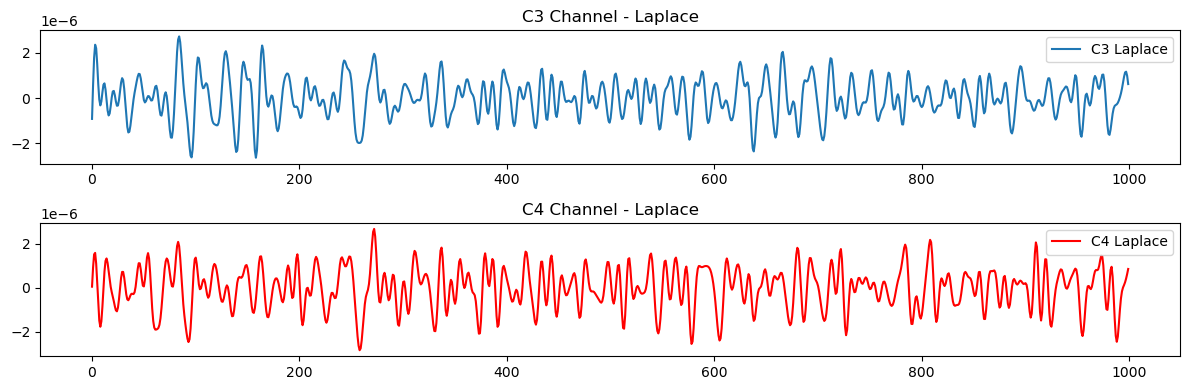

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].plot(data_laplace[trial_idx][3], label='C3 Laplace')
axes[1].plot(data_laplace[trial_idx][7], label='C4 Laplace', color='red')
axes[0].set_title('C3 Channel - Laplace')
axes[1].set_title('C4 Channel - Laplace')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

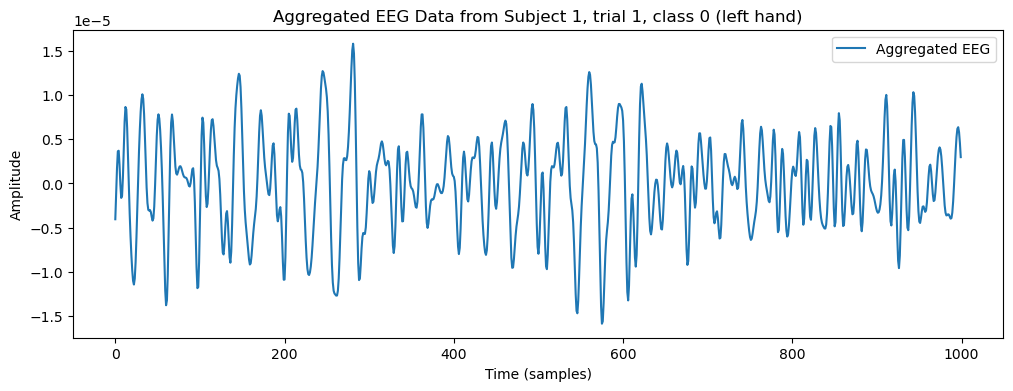

In [28]:
data_agg = channel_aggregation(data['X'])

plt.figure(figsize=(12, 4))
plt.plot(data_agg[trial_idx][0], label='Aggregated EEG')
plt.title('Aggregated EEG Data from Subject 1, trial 1, class 0 (left hand)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## EEG signal analisis for Subject 1, trial 72, class 1 (Right hand)

In [29]:
trial_idx = 71
print(data['y'][trial_idx])

1


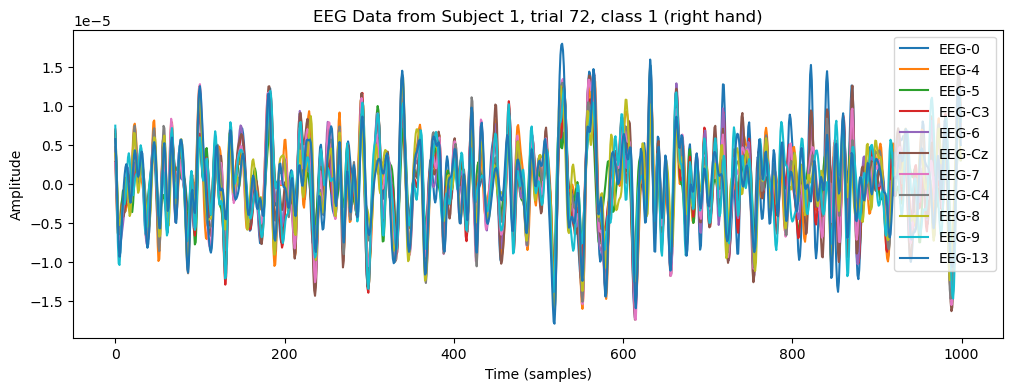

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][0], label='EEG-0')
plt.plot(data["X"][trial_idx][1], label='EEG-4')
plt.plot(data["X"][trial_idx][2], label='EEG-5')
plt.plot(data["X"][trial_idx][3], label='EEG-C3')
plt.plot(data["X"][trial_idx][4], label='EEG-6')
plt.plot(data["X"][trial_idx][5], label='EEG-Cz')
plt.plot(data["X"][trial_idx][6], label='EEG-7')
plt.plot(data["X"][trial_idx][7], label='EEG-C4')
plt.plot(data["X"][trial_idx][8], label='EEG-8')
plt.plot(data["X"][trial_idx][9], label='EEG-9')
plt.plot(data["X"][trial_idx][10], label='EEG-13')
plt.title('EEG Data from Subject 1, trial 72, class 1 (right hand)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

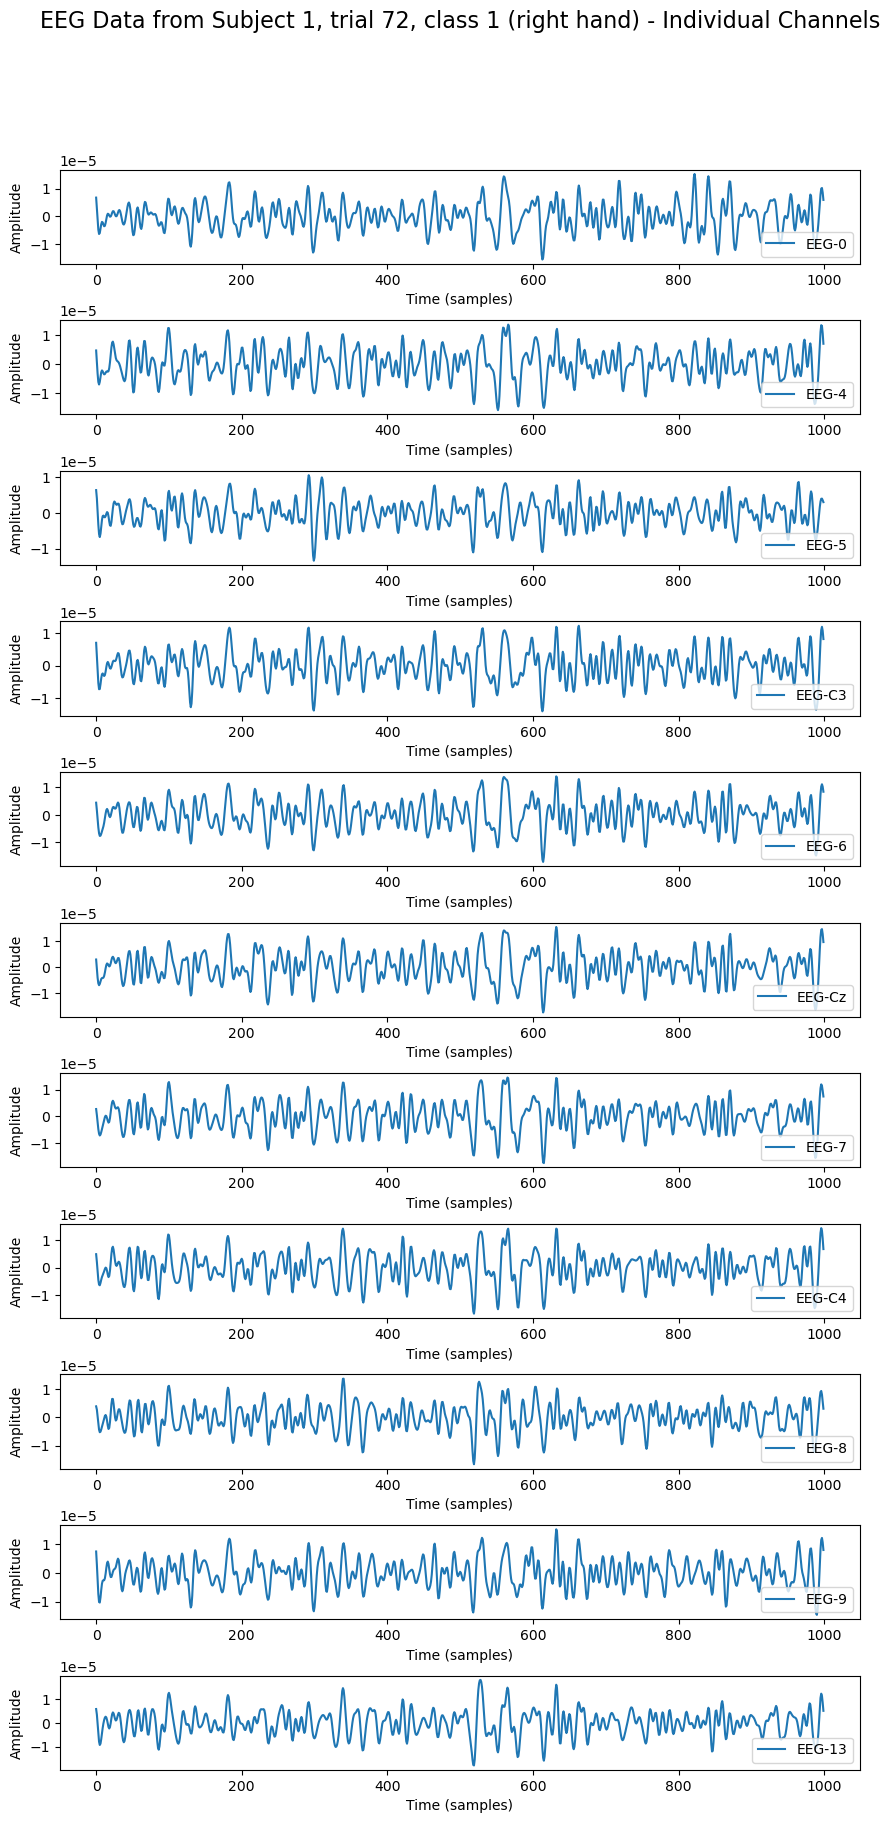

In [31]:
channel_labels = ['EEG-0', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7','EEG-C4', 'EEG-8', 'EEG-9', 'EEG-13']

fig, axes = plt.subplots(11, 1, figsize=(10, 20))

for i in range(11):
    axes[i].plot(data["X"][trial_idx][i], label=channel_labels[i])
    axes[i].set_xlabel('Time (samples)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='lower right')

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)

plt.suptitle('EEG Data from Subject 1, trial 72, class 1 (right hand) - Individual Channels', fontsize=16)
plt.show()

In [32]:
channels_laplace = [3,7] # C3 and C4
c3_neighbours = [0,2,4,9]
c4_neighbours = [1,6,8,10]

data_laplace = laplacian_filter(data['X'], channels_laplace, [c3_neighbours, c4_neighbours])

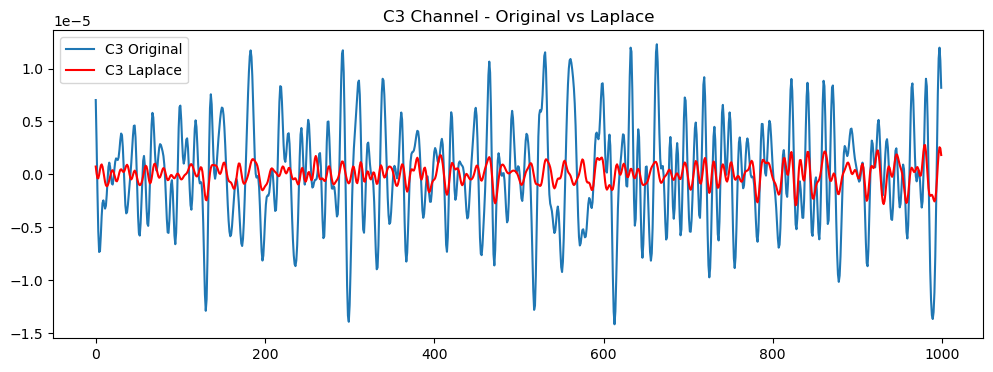

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][3], label='C3 Original')
plt.plot(data_laplace[trial_idx][3], label='C3 Laplace', color='red')
plt.title('C3 Channel - Original vs Laplace')
plt.legend()
plt.show()

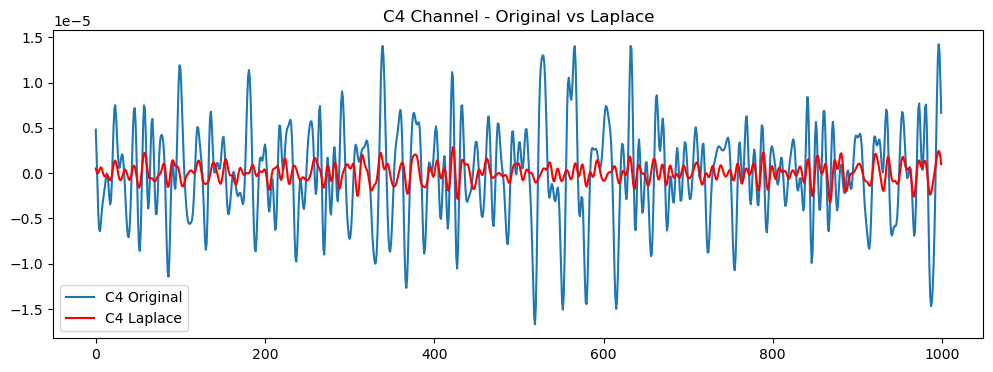

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(data["X"][trial_idx][7], label='C4 Original')
plt.plot(data_laplace[trial_idx][7], label='C4 Laplace', color='red')
plt.title('C4 Channel - Original vs Laplace')
plt.legend()
plt.show()

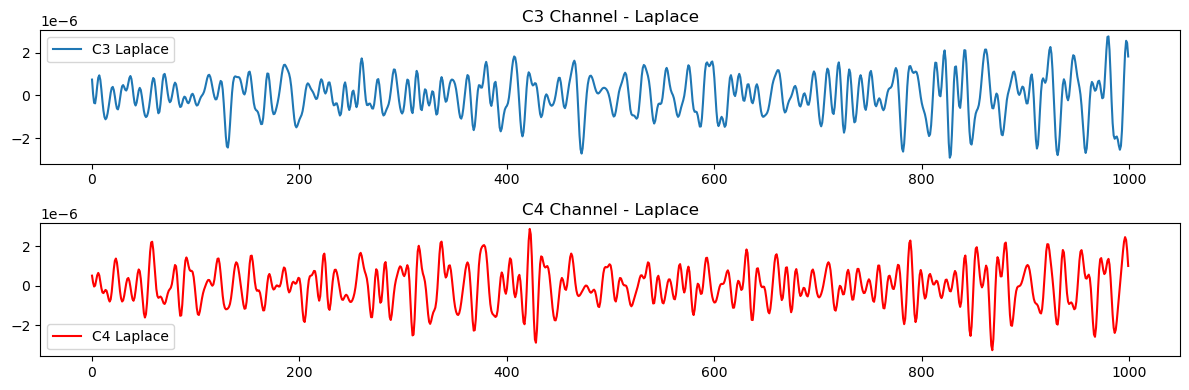

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].plot(data_laplace[trial_idx][3], label='C3 Laplace')
axes[1].plot(data_laplace[trial_idx][7], label='C4 Laplace', color='red')
axes[0].set_title('C3 Channel - Laplace')
axes[1].set_title('C4 Channel - Laplace')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

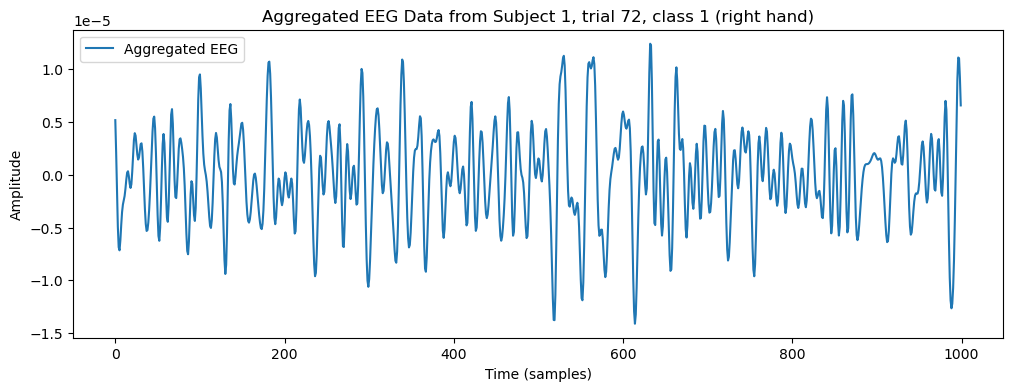

In [36]:
data_agg = channel_aggregation(data['X'])

plt.figure(figsize=(12, 4))
plt.plot(data_agg[trial_idx][0], label='Aggregated EEG')
plt.title('Aggregated EEG Data from Subject 1, trial 72, class 1 (right hand)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()